# Pre-processing Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import re
import zlib

from pathlib import Path
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GroupShuffleSplit, train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Helper functions for data collection
from scripts.collect_helper import check_cluster, pull_logs, get_collection_stats

## Connect to K8s cluster & Get all pods

In [2]:
check_cluster()

  Cluster Info

Total Nodes:
NAME           STATUS   ROLES           AGE     VERSION
k8s-master     Ready    control-plane   19d     v1.30.14
k8s-worker     Ready    worker          43h     v1.30.14
k8s-worker-2   Ready    worker          2d20h   v1.30.14
siem           Ready    siem            19d     v1.30.14

Benign Pods:
NAME                                      READY   STATUS    RESTARTS        AGE
flask-postgres-59676499f7-ntc8j           1/1     Running   0               2d20h
flask-todo-f5887d88-dzc5v                 1/1     Running   0               2d20h
flask-todo-f5887d88-hlmv4                 1/1     Running   1 (2d20h ago)   2d20h
mariadb-stimulator-5444785fc8-47bk4       1/1     Running   0               2d20h
mariadb-sysbench-67994b48d-kv46l          1/1     Running   0               2d20h
memcached-server-5c96d8b86-s4czd          1/1     Running   0               2d20h
memcached-stimulator-f6855656b-9bcq6      1/1     Running   0               2d20h
redis-server-7494cd

True

## Data Collection

Pull logs from Cilium dan Tetragon

In [3]:
#pull_logs(sessions=144, interval=600, stimulate=True)
#get_collection_stats()

In [4]:
with open("raw_logs/hubble.json") as f:
    hubble_malicious = [] 
    for line in f:
        if line.strip() and "bruteforce" in line.lower():
            try:
                hubble_malicious.append(json.loads(line))
            except json.JSONDecodeError:
                continue
            if len(hubble_malicious) >= 2:
                break

print(f"Hubble malicious:")
print(json.dumps(hubble_malicious, indent=1))

Hubble malicious:
[
 {
  "flow": {
   "time": "2026-06-20T11:03:23.910839456Z",
   "verdict": "DROPPED",
   "l4": {
    "ICMPv6": {
     "type": 133
    }
   },
   "source": {
    "identity": 30559,
    "cluster_name": "default",
    "labels": [
     "k8s:app.kubernetes.io/component=bruteforce",
     "k8s:app.kubernetes.io/instance=malicious",
     "k8s:app.kubernetes.io/name=malicious-containers",
     "k8s:io.cilium.k8s.namespace.labels.kubernetes.io/metadata.name=malicious",
     "k8s:io.cilium.k8s.policy.cluster=default",
     "k8s:io.cilium.k8s.policy.serviceaccount=default",
     "k8s:io.kubernetes.pod.namespace=malicious",
     "k8s:kids-label=1"
    ]
   },
   "destination": {
    "labels": [
     "reserved:unknown"
    ]
   },
   "Type": "L3_L4",
   "traffic_direction": "INGRESS"
  },
  "time": "2026-06-20T11:03:23.910839456Z"
 },
 {
  "flow": {
   "time": "2026-06-20T11:03:23.910839456Z",
   "verdict": "DROPPED",
   "l4": {
    "ICMPv6": {
     "type": 133
    }
   },
   "sou

In [5]:
with open("raw_logs/tetragon.json") as f:
    tetragon_socket = []
    for line in f:
        if line.strip() and "bruteforce" in line.lower():
            try:
                tetragon_socket.append(json.loads(line))
            except json.JSONDecodeError:
                continue
            if len(tetragon_socket) >= 2:
                break

print(f"\nTetragon socket:")
print(json.dumps(tetragon_socket, indent=1))


Tetragon socket:
[
 {
  "process_exit": {
   "process": {
    "exec_id": "azhzLXdvcmtlcjoxNzY0OTU4MjE1NDYxODI6Mjc5Mzg5",
    "pid": 279389,
    "uid": 0,
    "cwd": "/",
    "binary": "/bin/sh",
    "arguments": "-c \"apk add --no-cache hydra 2>/dev/null || apt-get install -y hydra 2>/dev/null || true\necho \"Starting brute-force attack simulation (throttled)...\"\n\nprintf 'admin\\nroot\\nuser\\ntest\\nguest\\n' > /tmp/users.txt\nprintf 'password\\n123456\\nadmin\\nroot\\nletmein\\nchangeme\\n' > /tmp/passwords.txt\n\nwhile true; do\n  echo \"[$(date)] === Brute-force cycle start ===\"\n\n  echo \"[$(date)] Attacking MariaDB...\"\n  hydra -L /tmp/users.txt -P /tmp/passwords.txt \\\n    mariadb-sysbench-service.benign-workloads.svc.cluster.local \\\n    mysql -t 1 -w 10 -f 2>&1 || true\n\n  sleep 120\n\n  echo \"[$(date)] Attacking WordPress...\"\n  hydra -L /tmp/users.txt -P /tmp/passwords.txt \\\n    wordpress-app.benign-workloads.svc.cluster.local \\\n    http-post-form \"/:usernam

In [6]:
"""Multi-class scenario labeling.

The pipeline stores:
  - scenario_label: detailed behavior/scenario class
  - label: alias for scenario_label for backward compatibility
"""

def load_label_config():
    candidates = [
        Path("label_mapping.json"),
        # Path("../feature_engineering/label_mapping.json"),
        # Path("../config/label_mapping.json"),
    ]
    for path in candidates:
        if path.exists():
            with open(path) as f:
                return json.load(f), path
    return DEFAULT_LABEL_CONFIG, None

LABEL_CONFIG, LABEL_CONFIG_PATH = load_label_config()
SCENARIO_CLASS_NAMES = LABEL_CONFIG.get("scenario_class_names", LABEL_CONFIG.get("class_names", []))
CLASS_NAMES = SCENARIO_CLASS_NAMES
LABEL_NAMES = {i: name for i, name in enumerate(SCENARIO_CLASS_NAMES)}
LABEL_RULES = sorted(
    LABEL_CONFIG["rules"],
    key=lambda rule: len(rule["pattern"]),
    reverse=True,
)

def normalize_name(value):
    return (value or "").lower().replace("_", "-")

def get_label_info(pod_name, namespace=None):
    pod_lower = normalize_name(pod_name)
    ns_lower = normalize_name(namespace) if namespace else None
    for rule in LABEL_RULES:
        rule_ns = rule.get("namespace")
        if rule_ns and ns_lower and normalize_name(rule_ns) != ns_lower:
            continue
        if normalize_name(rule["pattern"]) in pod_lower:
            return int(rule.get("scenario_label", rule.get("label")))
    return -1

def get_label(pod_name, namespace=None):
    return get_label_info(pod_name, namespace)

print(f"Label config: {LABEL_CONFIG_PATH or 'built-in fallback'}")
print(f"Scenario labels: {SCENARIO_CLASS_NAMES}")
print("Rules:")
for rule in LABEL_RULES:
    scenario = int(rule.get("scenario_label", rule.get("label")))
    print(f"  scenario {scenario}: [{rule.get('namespace', '*')}] {rule['pattern']}")

Label config: label_mapping.json
Scenario labels: ['Botnet', 'Cryptominer', 'Trojan-Agent', 'Cloud Attack', 'Brute-Force', 'Data-Caching', 'Database', 'Redis', 'Web-Serving']
Rules:
  scenario 8: [benign-workloads] web-serving-stimulator
  scenario 5: [benign-workloads] memcached-stimulator
  scenario 6: [benign-workloads] mariadb-stimulator
  scenario 7: [benign-workloads] redis-stimulator
  scenario 6: [benign-workloads] wordpress-mysql
  scenario 6: [benign-workloads] flask-postgres
  scenario 8: [benign-workloads] wordpress-app
  scenario 8: [benign-workloads] web-serving
  scenario 4: [malicious] bruteforce
  scenario 8: [benign-workloads] flask-todo
  scenario 1: [malicious] coinminer
  scenario 5: [benign-workloads] memcached
  scenario 6: [benign-workloads] sysbench
  scenario 3: [malicious] stratus
  scenario 6: [benign-workloads] mariadb
  scenario 0: [malicious] mirai
  scenario 1: [malicious] miner
  scenario 2: [malicious] agent
  scenario 7: [benign-workloads] redis


## 2. Parse Tetragon (Syscall) - Per Pod 5-grams

In [7]:
def session_id_from_path(path):
    match = re.search(r"_session_(\d+)\.json$", str(path))
    return int(match.group(1)) if match else 0


def iter_json_records(filepath):
    """Read either NDJSON or a JSON array/object without loading broken lines."""
    with open(filepath) as f:
        try:
            data = json.load(f)
            if isinstance(data, list):
                yield from data
            else:
                yield data
            return
        except json.JSONDecodeError:
            f.seek(0)

        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

def tetragon_log_paths():
    # Prioritize per-session files to preserve session_id from filename
    session_paths = sorted(
        Path("raw_logs/sessions").glob("tetragon_session_*.json"),
        key=session_id_from_path,
    )
    if session_paths:
        return session_paths
    # Fallback to merged (session_id will be 0 for all records)
    merged = Path("raw_logs/tetragon.json")
    if merged.exists():
        return [merged]
    return sorted(Path("raw_logs").glob("*_tetragon.json")) or [merged]

def parse_tetragon_file(filepath):
    records = []
    session_id = session_id_from_path(filepath)

    for event_index, entry in enumerate(iter_json_records(filepath)):
        try:
            event_type = None
            process = {}
            syscall = ""

            if "process_kprobe" in entry:
                event_type = "kprobe"
                kprobe = entry["process_kprobe"]
                process = kprobe.get("process", {})
                syscall = kprobe.get("function_name", "")
            elif "process_exec" in entry:
                event_type = "exec"
                process = entry["process_exec"].get("process", {})
                syscall = entry["process_exec"].get("function_name") or "__x64_sys_execve"
            elif "process_exit" in entry:
                event_type = "exit"
                process = entry["process_exit"].get("process", {})
                syscall = "__x64_sys_exit_group"
            else:
                continue

            pod = process.get("pod", {})
            container = process.get("container", {})
            pod_name = pod.get("name", "")
            namespace = pod.get("namespace", "")
            # scenario_label = get_label_info(pod_name)
            scenario_label = get_label_info(pod_name, namespace)
            label = scenario_label

            records.append({
                "session_id": session_id,
                "event_index": event_index,
                "event_type": event_type,
                "timestamp": entry.get("timestamp", ""),
                "pod_name": pod_name,
                "namespace": namespace,
                "container": container.get("name", ""),
                "binary": process.get("binary", ""),
                "syscall": syscall,
                "label": scenario_label,
                "scenario_label": scenario_label,
            })
        except Exception:
            continue

    return records

def parse_tetragon():
    records = []
    paths = tetragon_log_paths()
    for path in paths:
        records.extend(parse_tetragon_file(path))

    df = pd.DataFrame(records)
    unknown = df[df["label"] < 0].copy()
    if not unknown.empty:
        print(f"Skipped {len(unknown):,} unlabeled Tetragon events. Top unknown pods:")
        print(unknown.groupby(["namespace", "pod_name"]).size().sort_values(ascending=False).head(15))

    df = df[df["label"] >= 0].copy()
    print(f"Parsed {len(df):,} labeled Tetragon events from {len(paths)} file(s)")
    print(f"Labels: {df['label'].value_counts().sort_index().to_dict()}")
    print(f"Sessions: {df['session_id'].nunique()}")
    return df

tetragon_df = parse_tetragon()
# tetragon_df[tetragon_df["pod_name"].str.contains("bruteforce")].head()
# tetragon_df.head()

# Sample top pods per label
tetragon_df.groupby(["label", "namespace", "pod_name"]).size().reset_index(name="count").sort_values(["label", "count"], ascending=[True, False]).groupby("label").head(1)

Skipped 297,310 unlabeled Tetragon events. Top unknown pods:
namespace           pod_name                              
wazuh               wazuh-agent-mf76g                         99337
                    wazuh-manager-0                           73486
                    wazuh-indexer-0                           73239
                    wazuh-dashboard-684977b49d-kkmwn          12662
default             trojan-agent-7f77855654-tzdrg             10584
wazuh               wazuh-agent-b4t8t                          9738
default             app-server-6d65b7866d-c2mzw                6001
wazuh               wazuh-agent-sk7qd                          5880
local-path-storage  local-path-provisioner-c7c649777-88qrr     3840
wazuh               wazuh-agent-64mb8                          2543
dtype: int64
Parsed 1,175,942 labeled Tetragon events from 153 file(s)
Labels: {0: 1779, 1: 90449, 2: 85020, 3: 132802, 4: 5355, 5: 61312, 6: 155448, 7: 586036, 8: 57741}
Sessions: 110


,label,namespace,pod_name,count
0,0,malicious,malicious-mirai-bb9d6d889-7cb4m,1074
3,1,malicious,malicious-coinminer-7949c59578-d29jt,63870
6,2,malicious,malicious-agent-5fbff4b495-b7mmf,55585
8,3,malicious,malicious-stratus-74b5f8d49d-bcksx,132802
9,4,malicious,malicious-bruteforce-598fcb7469-vfj8c,5321
13,5,benign-workloads,memcached-stimulator-f6855656b-9bcq6,61312
15,6,benign-workloads,mariadb-stimulator-5444785fc8-47bk4,140795
18,7,benign-workloads,redis-server-7494cd467c-zqhtr,387229
23,8,benign-workloads,web-serving-stimulator-6769749d65-xwx8t,46602


In [8]:
SYSCALL_MAP = {
    "__x64_sys_read": 0,
    "__x64_sys_write": 1,
    "__x64_sys_open": 2,
    "__x64_sys_close": 3,
    "__x64_sys_stat": 4,
    "__x64_sys_fstat": 5,
    "__x64_sys_mmap": 9,
    "__x64_sys_mprotect": 10,
    "__x64_sys_munmap": 11,
    "__x64_sys_brk": 12,
    "__x64_sys_rt_sigaction": 13,
    "__x64_sys_rt_sigreturn": 15,
    "__x64_sys_ioctl": 16,
    "__x64_sys_access": 21,
    "__x64_sys_sched_yield": 24,
    "__x64_sys_nanosleep": 35,
    "__x64_sys_socket": 41,
    "__x64_sys_connect": 42,
    "__x64_sys_accept": 43,
    "__x64_sys_sendto": 44,
    "__x64_sys_recvfrom": 45,
    "__x64_sys_clone": 56,
    "__x64_sys_fork": 57,
    "__x64_sys_execve": 59,
    "__x64_sys_exit": 60,
    "__x64_sys_exit_group": 231,
    "__x64_sys_wait4": 61,
    "__x64_sys_kill": 62,
    "__x64_sys_openat": 257,
    "__x64_sys_newfstatat": 262,
    "__x64_sys_epoll_pwait": 281,
}

def stable_syscall_number(syscall):
    if syscall in SYSCALL_MAP:
        return SYSCALL_MAP[syscall]
    if not syscall:
        return -1
    # Avoid Python's randomized hash(), which changes values between processes.
    return 1000 + (zlib.crc32(syscall.encode("utf-8")) % 1000)

tetragon_df["syscall_num"] = tetragon_df["syscall"].apply(stable_syscall_number)

unmapped = tetragon_df[~tetragon_df["syscall"].isin(SYSCALL_MAP)]["syscall"].value_counts()
if len(unmapped) > 0:
    print(f"Unmapped syscalls kept with stable ids: {unmapped.head(20).to_dict()}")

tetragon_df = tetragon_df[tetragon_df["syscall_num"] >= 0].copy()

def generate_ngrams(sequence, n=5):
    return [tuple(sequence[i:i+n]) for i in range(len(sequence) - n + 1)]

def ngrams_to_doc(sequence, n=5):
    """Convert syscall sequence to space-separated n-gram tokens (bag-of-n-grams document)."""
    grams = generate_ngrams(sequence, n)
    return " ".join("_".join(map(str, g)) for g in grams)

group_cols = ["session_id", "pod_name", "namespace", "label"]
syscall_seqs = (
    tetragon_df
    .sort_values(["session_id", "pod_name", "event_index"])
    .groupby(group_cols)["syscall_num"]
    .apply(list)
    .reset_index(name="sequence")
)

# Unit of classification: 1 row = 1 pod-session window (bag-of-n-grams)
syscall_seqs["ngram_doc"] = syscall_seqs["sequence"].apply(lambda seq: ngrams_to_doc(seq, 5))
syscall_seqs["scenario_label"] = syscall_seqs["label"]

# Keep only windows with enough syscalls to form at least one 5-gram
syscall_seqs = syscall_seqs[syscall_seqs["ngram_doc"].str.len() > 0].copy()

# syscall_dataset now has 1 row per pod-session, not per 5-gram
syscall_dataset = syscall_seqs[["session_id", "pod_name", "namespace", "label", "scenario_label", "ngram_doc"]].copy()

print(f"Syscall: {len(syscall_dataset):,} pod-session windows")
print(f"Labels: {syscall_dataset['label'].value_counts().sort_index().to_dict()}")
print(f"Duplicate full rows: {syscall_dataset.duplicated().sum():,}")
syscall_dataset.groupby(["label", "pod_name"]).size().reset_index(name="count").sort_values(["label", "count"], ascending=[True, False]).groupby("label").head(1)


Syscall: 1,207 pod-session windows
Labels: {0: 7, 1: 187, 2: 52, 3: 27, 4: 5, 5: 80, 6: 293, 7: 181, 8: 375}
Duplicate full rows: 0


,label,pod_name,count
0,0,malicious-mirai-bb9d6d889-7cb4m,4
5,1,malicious-miner-64b8444954-vxw75,78
6,2,malicious-agent-5fbff4b495-b7mmf,26
8,3,malicious-stratus-74b5f8d49d-bcksx,27
9,4,malicious-bruteforce-598fcb7469-vfj8c,4
11,5,memcached-stimulator-f6855656b-9bcq6,80
13,6,mariadb-stimulator-5444785fc8-47bk4,82
16,7,redis-server-7494cd467c-zqhtr,92
18,8,flask-todo-f5887d88-hlmv4,87


## 3. Parse Hubble (NetworkFlow) Features

In [9]:
def hubble_log_paths():
    # Prioritize per-session files to preserve session_id from filename
    session_paths = sorted(
        Path("raw_logs/sessions").glob("hubble_session_*.json"),
        key=session_id_from_path,
    )
    if session_paths:
        return session_paths
    # Fallback to merged (session_id will be 0 for all records)
    merged = Path("raw_logs/hubble.json")
    if merged.exists():
        return [merged]
    return sorted(Path("raw_logs").glob("*_hubble.json")) or [merged]

def endpoint_info(endpoint):
    pod_name = endpoint.get("pod_name", "") or ""
    namespace = endpoint.get("namespace", "") or ""
    scenario_label = get_label_info(pod_name, namespace)  # ← tambah namespace
    return {
        "pod_name": pod_name,
        "namespace": namespace,
        "scenario_label": scenario_label,
    }

def choose_labeled_endpoint(flow):
    src = endpoint_info(flow.get("source", {}))
    dst = endpoint_info(flow.get("destination", {}))
    direction = flow.get("traffic_direction", "")

    src_labeled = src["scenario_label"] >= 0
    dst_labeled = dst["scenario_label"] >= 0

    # Prefer the endpoint represented by Hubble traffic_direction when it has a label.
    if direction == "EGRESS" and src_labeled:
        return src, "source"
    if direction == "INGRESS" and dst_labeled:
        return dst, "destination"

    # If the direction endpoint is unlabeled, keep the flow when the opposite endpoint is labeled.
    if src_labeled and not dst_labeled:
        return src, "source"
    if dst_labeled and not src_labeled:
        return dst, "destination"

    # For service-to-service flows where both endpoints are labeled, keep a deterministic perspective.
    if src_labeled and dst_labeled:
        if direction == "INGRESS":
            return dst, "destination"
        return src, "source"

    # Preserve one endpoint for unknown-flow diagnostics in parse_hubble().
    fallback = src if src["pod_name"] else dst
    return fallback, "unknown"

def parse_hubble_file(filepath):
    records = []
    session_id = session_id_from_path(filepath)

    for flow_index, entry in enumerate(iter_json_records(filepath)):
        try:
            flow = entry.get("flow", {})
            if not flow:
                continue

            endpoint, flow_perspective = choose_labeled_endpoint(flow)
            pod_name = endpoint["pod_name"]
            namespace = endpoint["namespace"]
            if not pod_name:
                continue

            scenario_label = endpoint["scenario_label"]
            label = scenario_label

            l4 = flow.get("l4", {})
            tcp = l4.get("TCP", {})
            udp = l4.get("UDP", {})
            flags = tcp.get("flags", {})
            dst_port = int(tcp.get("destination_port", udp.get("destination_port", 0)) or 0)
            src_port = int(tcp.get("source_port", udp.get("source_port", 0)) or 0)

            records.append({
                "session_id": session_id,
                "flow_index": flow_index,
                "pod_name": pod_name,
                "namespace": namespace,
                "label": scenario_label,
                "scenario_label": scenario_label,
                "traffic_dir": flow.get("traffic_direction", "UNKNOWN"),
                "flow_perspective": flow_perspective,
                "proto_TCP": int(bool(tcp)),
                "proto_UDP": int(bool(udp)),
                "proto_OTHER": int(not tcp and not udp),
                "dir_EGRESS": int(flow.get("traffic_direction") == "EGRESS"),
                "dir_INGRESS": int(flow.get("traffic_direction") == "INGRESS"),
                "verdict_FORWARDED": int(flow.get("verdict") == "FORWARDED"),
                "verdict_DROPPED": int(flow.get("verdict") == "DROPPED"),
                "verdict_TRACED": int(flow.get("verdict") == "TRACED"),
                "flag_SYN": int(flags.get("SYN", False)),
                "flag_ACK": int(flags.get("ACK", False)),
                "flag_FIN": int(flags.get("FIN", False)),
                "flag_RST": int(flags.get("RST", False)),
                "flag_PSH": int(flags.get("PSH", False)),
                "flag_URG": int(flags.get("URG", False)),
                "is_reply": int(flow.get("is_reply", False)),
                "src_port": src_port,
                "dst_port": dst_port,
                "is_well_known_port": int(0 < dst_port < 1024),
                "is_high_port": int(dst_port > 49152),
                "is_dns_port": int(dst_port == 53),
                "is_http_port": int(dst_port in [80, 443, 8080, 8443]),
                "is_db_port": int(dst_port in [3306, 5432, 6379, 11211]),
                "is_mining_port": int(dst_port in [3333, 4444, 5555, 7777, 8888, 9999, 14444, 45700]),
            })
        except Exception:
            continue

    return records

def parse_hubble():
    records = []
    paths = hubble_log_paths()
    for path in paths:
        records.extend(parse_hubble_file(path))

    df = pd.DataFrame(records)
    unknown = df[df["label"] < 0].copy()
    if not unknown.empty:
        print(f"Skipped {len(unknown):,} unlabeled Hubble flows. Top unknown pods:")
        print(unknown.groupby(["namespace", "pod_name"]).size().sort_values(ascending=False).head(15))

    df = df[df["label"] >= 0].copy()
    if not df.empty and "flow_perspective" in df.columns:
        print(f"Flow perspectives: {df['flow_perspective'].value_counts().to_dict()}")
    print(f"Parsed {len(df):,} labeled Hubble flows from {len(paths)} file(s)")
    print(f"Labels: {df['label'].value_counts().sort_index().to_dict()}")
    print(f"Sessions: {df['session_id'].nunique()}")
    return df

network_events = parse_hubble()
# network_events.head()
# Sample per label
network_events.groupby(["label", "namespace", "pod_name"]).size().reset_index(name="count").sort_values(["label", "count"], ascending=[True, False]).groupby("label").head(1)

Skipped 6,560,099 unlabeled Hubble flows. Top unknown pods:
namespace    pod_name                        
default      cache-worker-5d8785b649-2b8zc       5597471
             frontend-844c4b6748-nj6v6            521925
kube-system  coredns-55cb58b774-spgqq             204772
             coredns-55cb58b774-5gvr2             190802
default      backend-api-7789d4554d-xs7t4          21740
             trojan-agent-7f77855654-tzdrg         17133
wazuh        wazuh-indexer-0                        1475
kube-system  hubble-relay-7dcdb44c8f-tvvb7          1365
wazuh        wazuh-dashboard-684977b49d-kkmwn       1206
kube-system  hubble-ui-59bb4cb67b-rjg7v             1192
wazuh        wazuh-manager-0                        1018
dtype: int64
Flow perspectives: {'source': 8337302, 'destination': 5575953}
Parsed 13,913,255 labeled Hubble flows from 189 file(s)
Labels: {0: 110767, 1: 1956929, 2: 1359015, 3: 1857590, 4: 122726, 5: 3575563, 6: 511510, 7: 3802030, 8: 617125}
Sessions: 178


,label,namespace,pod_name,count
1,0,malicious,malicious-mirai-bb9d6d889-7dh49,53399
5,1,malicious,malicious-miner-64b8444954-vxw75,1946479
6,2,malicious,malicious-agent-5fbff4b495-b7mmf,1230215
8,3,malicious,malicious-stratus-74b5f8d49d-bcksx,1857590
9,4,malicious,malicious-bruteforce-598fcb7469-vfj8c,120434
16,5,benign-workloads,memcached-stimulator-f6855656b-9bcq6,3223204
18,6,benign-workloads,mariadb-stimulator-5444785fc8-47bk4,429561
22,7,benign-workloads,redis-stimulator-c9695fb59-6kcfx,2883942
26,8,benign-workloads,web-serving-stimulator-6769749d65-xwx8t,524804


## 4. Feature Selection (Network)

SelectKBest k=20 dengan chi-squared

Network rows after per-pod flow-window aggregation: 140,798
Window size: 100 flows
Features after removing zero-variance: 26
Labels: {0: 1353, 1: 19665, 2: 13758, 3: 18650, 4: 1285, 5: 35889, 6: 5442, 7: 38171, 8: 6585}
Duplicate feature rows: 117,063

Selected top 20 network features:
  proto_OTHER_count: 2417456.93
  is_db_port_count: 1548157.38
  is_http_port_count: 1456470.78
  proto_TCP_count: 1033576.35
  verdict_DROPPED_count: 970343.44
  is_mining_port_count: 665333.59
  is_well_known_port_count: 574954.28
  flag_SYN_count: 547763.78
  is_dns_port_count: 543370.70
  proto_UDP_count: 501196.96
  dir_INGRESS_count: 451518.30
  flag_RST_count: 333648.16
  verdict_FORWARDED_count: 291051.23
  flag_ACK_count: 255481.06
  dir_EGRESS_count: 231618.80
  verdict_TRACED_count: 201531.26
  unique_src_ports: 100221.66
  is_high_port_count: 98564.37
  unique_dst_ports: 98084.18
  flag_FIN_count: 77219.97


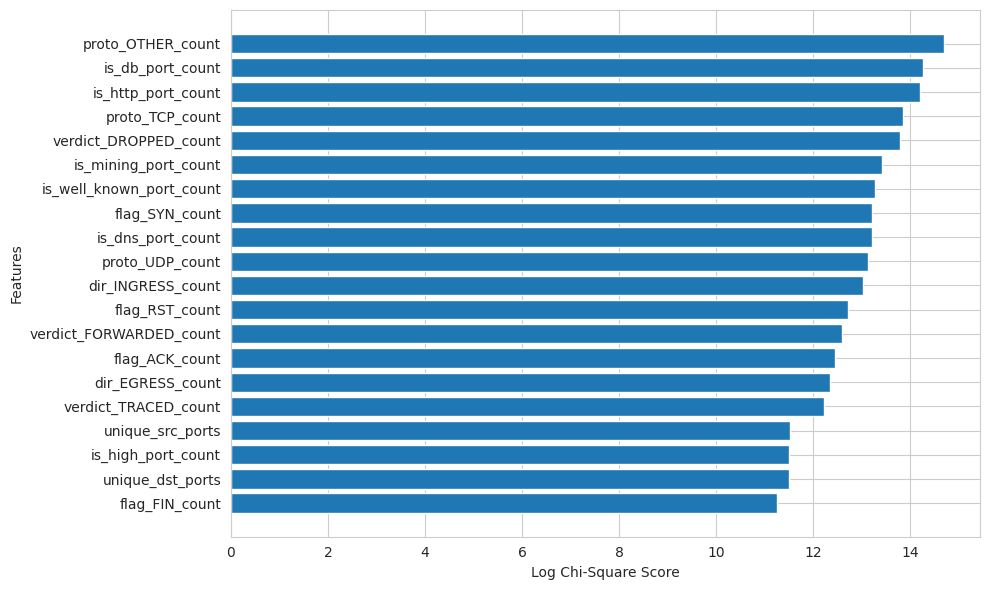

In [10]:
metadata_cols = [
    "session_id", "pod_name", "namespace", "label",
    "scenario_label", "flow_window",
]
count_cols = [
    "proto_TCP", "proto_UDP", "proto_OTHER",
    "dir_EGRESS", "dir_INGRESS",
    "verdict_FORWARDED", "verdict_DROPPED", "verdict_TRACED",
    "flag_SYN", "flag_ACK", "flag_FIN", "flag_RST", "flag_PSH", "flag_URG",
    "is_well_known_port", "is_high_port", "is_dns_port", "is_http_port",
    "is_db_port", "is_mining_port",
]

if network_events.empty:
    raise ValueError("No labeled Hubble events were parsed.")

# Window Hubble flows within each pod-session. Without this, grouping by only
# session_id/pod_name collapses all flows from a pod-session into one row.
NETWORK_WINDOW_SIZE = 100
network_events = network_events.sort_values(["session_id", "pod_name", "flow_index"]).copy()
network_events["flow_window"] = (
    network_events
    .groupby(["session_id", "pod_name", "namespace", "label"])
    .cumcount()
    // NETWORK_WINDOW_SIZE
).astype(int)

agg = (
    network_events
    .groupby(metadata_cols)
    .agg(
        flow_count=("flow_index", "count"),
        unique_src_ports=("src_port", "nunique"),
        unique_dst_ports=("dst_port", "nunique"),
        reply_ratio=("is_reply", "mean"),
        **{f"{col}_count": (col, "sum") for col in count_cols}
    )
    .reset_index()
)

for base in ["EGRESS", "INGRESS"]:
    col = f"dir_{base}_count"
    if col not in agg:
        agg[col] = 0

agg["egress_ratio"] = agg["dir_EGRESS_count"] / agg["flow_count"].clip(lower=1)
agg["ingress_ratio"] = agg["dir_INGRESS_count"] / agg["flow_count"].clip(lower=1)
agg["syn_ack_ratio"] = agg["flag_SYN_count"] / agg["flag_ACK_count"].replace(0, np.nan)
agg["syn_ack_ratio"] = agg["syn_ack_ratio"].fillna(0)

network_dataset = agg.fillna(0)

X_flow = network_dataset.drop(columns=metadata_cols)
y_flow = network_dataset["scenario_label"]

variance = X_flow.var()
non_zero_cols = variance[variance > 0].index.tolist()
X_flow = X_flow[non_zero_cols]

print(f"Network rows after per-pod flow-window aggregation: {len(network_dataset):,}")
print(f"Window size: {NETWORK_WINDOW_SIZE} flows")
print(f"Features after removing zero-variance: {len(non_zero_cols)}")
print(f"Labels: {y_flow.value_counts().sort_index().to_dict()}")
print(f"Duplicate feature rows: {X_flow.duplicated().sum():,}")

k = min(20, len(non_zero_cols))
selector = SelectKBest(chi2, k=k)
X_flow_selected = selector.fit_transform(X_flow.abs(), y_flow)

selected_features = X_flow.columns[selector.get_support()].tolist()
scores = selector.scores_[selector.get_support()]

print(f"\nSelected top {k} network features:")
for feat, score in sorted(zip(selected_features, scores), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {score:.2f}")

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(scores)
plt.barh([selected_features[i] for i in sorted_idx], np.log1p(scores[sorted_idx]))
plt.xlabel("Log Chi-Square Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("output/network_feature_importance.png", dpi=150)
plt.show()

## 5. Split Sanity Check

In [11]:
def grouped_split_summary(df, name):
    y = df["scenario_label"] if "scenario_label" in df.columns else df["label"]

    # Use session_id grouping if multiple sessions, else fall back to label-stratified split
    # This avoids the problem where a single pod per label causes entire labels to be in only train or test
    if df["session_id"].nunique() > 1:
        group_col = "session_id"
        groups = df[group_col]
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(splitter.split(df, y, groups=groups))
        split_method = f"GroupShuffle by {group_col}"
    else:
        # Stratified split by label to ensure all labels appear in both train and test
        from sklearn.model_selection import train_test_split as tts
        idx = df.index.tolist()
        train_idx, test_idx = tts(idx, test_size=0.3, random_state=42, stratify=y)
        split_method = "Stratified by label"

    print(f"=== {name} ===")
    print(f"Split method: {split_method}")
    print(f"Train: {len(train_idx):,} | Test: {len(test_idx):,}")
    print(f"Train labels: {Counter(y.iloc[train_idx])}")
    print(f"Test labels : {Counter(y.iloc[test_idx])}")

grouped_split_summary(syscall_dataset, "Syscall Dataset")
grouped_split_summary(network_dataset, "Network Flow Dataset")

=== Syscall Dataset ===
Split method: GroupShuffle by session_id
Train: 866 | Test: 341
Train labels: Counter({8: 265, 6: 214, 1: 141, 7: 129, 5: 57, 2: 37, 3: 17, 4: 4, 0: 2})
Test labels : Counter({8: 110, 6: 79, 7: 52, 1: 46, 5: 23, 2: 15, 3: 10, 0: 5, 4: 1})
=== Network Flow Dataset ===
Split method: GroupShuffle by session_id
Train: 98,358 | Test: 42,440
Train labels: Counter({7: 27097, 5: 25423, 1: 13427, 3: 12733, 2: 9366, 8: 4621, 6: 3825, 0: 971, 4: 895})
Test labels : Counter({7: 11074, 5: 10466, 1: 6238, 3: 5917, 2: 4392, 8: 1964, 6: 1617, 4: 390, 0: 382})


## 6. Save Datasets

In [12]:
Path("dataset").mkdir(exist_ok=True)
Path("output").mkdir(exist_ok=True)

syscall_dataset.to_csv("dataset/syscall_dataset.csv", index=False)
print(f"Saved syscall_dataset.csv ({len(syscall_dataset):,} rows)")

flow_df_selected = network_dataset[metadata_cols].copy()
flow_df_selected[selected_features] = pd.DataFrame(
    X_flow_selected,
    columns=selected_features,
    index=network_dataset.index,
)
flow_df_selected.to_csv("dataset/network_flow_dataset.csv", index=False)
print(f"Saved network_flow_dataset.csv ({len(flow_df_selected):,} rows)")

joblib.dump(selector, "dataset/feature_selector.pkl")
joblib.dump(selected_features, "dataset/selected_features.pkl")

print("\n=== Summary ===")
print(f"Syscall: {len(syscall_dataset):,} 5-grams | Labels: {Counter(syscall_dataset['scenario_label'])}")
print(f"Network: {len(flow_df_selected):,} flow-window rows | Labels: {Counter(flow_df_selected['scenario_label'])}")
print(f"Selected network features: {selected_features}")

Saved syscall_dataset.csv (1,207 rows)
Saved network_flow_dataset.csv (140,798 rows)

=== Summary ===
Syscall: 1,207 5-grams | Labels: Counter({8: 375, 6: 293, 1: 187, 7: 181, 5: 80, 2: 52, 3: 27, 0: 7, 4: 5})
Network: 140,798 flow-window rows | Labels: Counter({7: 38171, 5: 35889, 1: 19665, 3: 18650, 2: 13758, 8: 6585, 6: 5442, 0: 1353, 4: 1285})
Selected network features: ['unique_src_ports', 'unique_dst_ports', 'proto_TCP_count', 'proto_UDP_count', 'proto_OTHER_count', 'dir_EGRESS_count', 'dir_INGRESS_count', 'verdict_FORWARDED_count', 'verdict_DROPPED_count', 'verdict_TRACED_count', 'flag_SYN_count', 'flag_ACK_count', 'flag_FIN_count', 'flag_RST_count', 'is_well_known_port_count', 'is_high_port_count', 'is_dns_port_count', 'is_http_port_count', 'is_db_port_count', 'is_mining_port_count']


## 7. Visualization

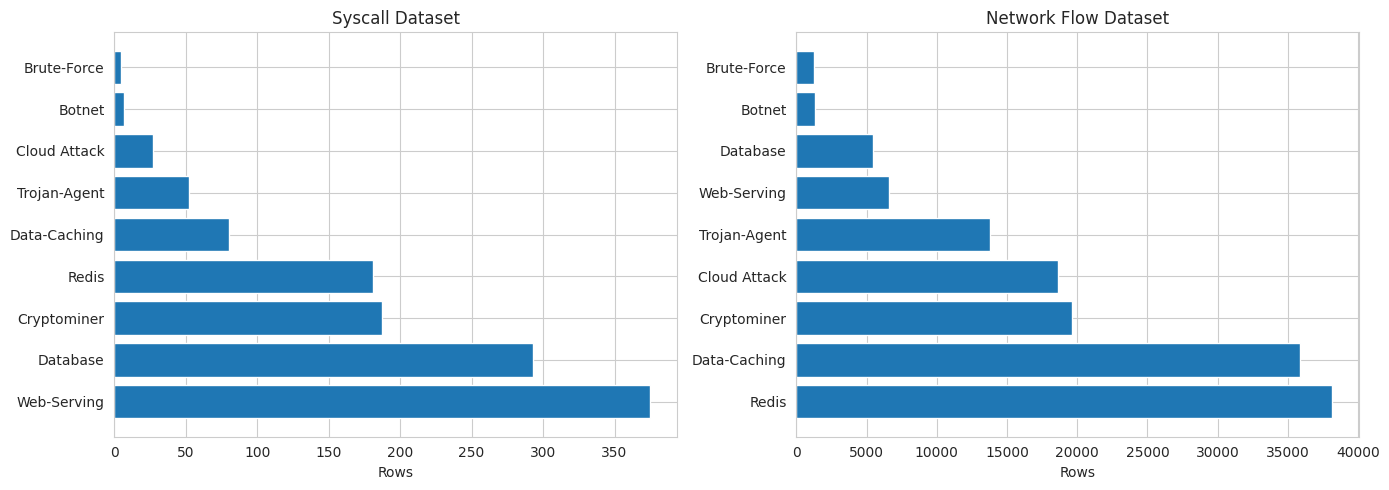

Preprocessing complete.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

syscall_counts = syscall_dataset["scenario_label"].map(LABEL_NAMES).value_counts()
axes[0].barh(syscall_counts.index, syscall_counts.values)
axes[0].set_title("Syscall Dataset")
axes[0].set_xlabel("Rows")

flow_counts = flow_df_selected["scenario_label"].map(LABEL_NAMES).value_counts()
axes[1].barh(flow_counts.index, flow_counts.values)
axes[1].set_title("Network Flow Dataset")
axes[1].set_xlabel("Rows")

plt.tight_layout()
plt.savefig("output/label_distribution.png", dpi=150)
plt.show()

print("Preprocessing complete.")